===== DOCUMENTOS POR JURISDICCIÓN =====
jurisdiction
chile        133
mexico        76
argentina     64
espana        32
Name: count, dtype: int64

===== JURISDICCIONES DETECTADAS =====
['argentina', 'chile', 'espana', 'mexico']

===== PROCESANDO: ARGENTINA =====
Documentos: 64
✅ argentina: 15750 términos extraídos
      jurisdiction                     term  frequency
4230     argentina               daño moral         48
2110     argentina             buenos aires         32
5503     argentina           domicilio real         22
3783     argentina            corte suprema         22
4294     argentina         daños perjuicios         20
9599     argentina                  mi hijo         16
14614    argentina  suprema justicia nación         16
14613    argentina         suprema justicia         16
8740     argentina          justicia nación         16
3786     argentina   corte suprema justicia         16

===== PROCESANDO: CHILE =====
Documentos: 133
✅ chile: 20882 términos extraíd

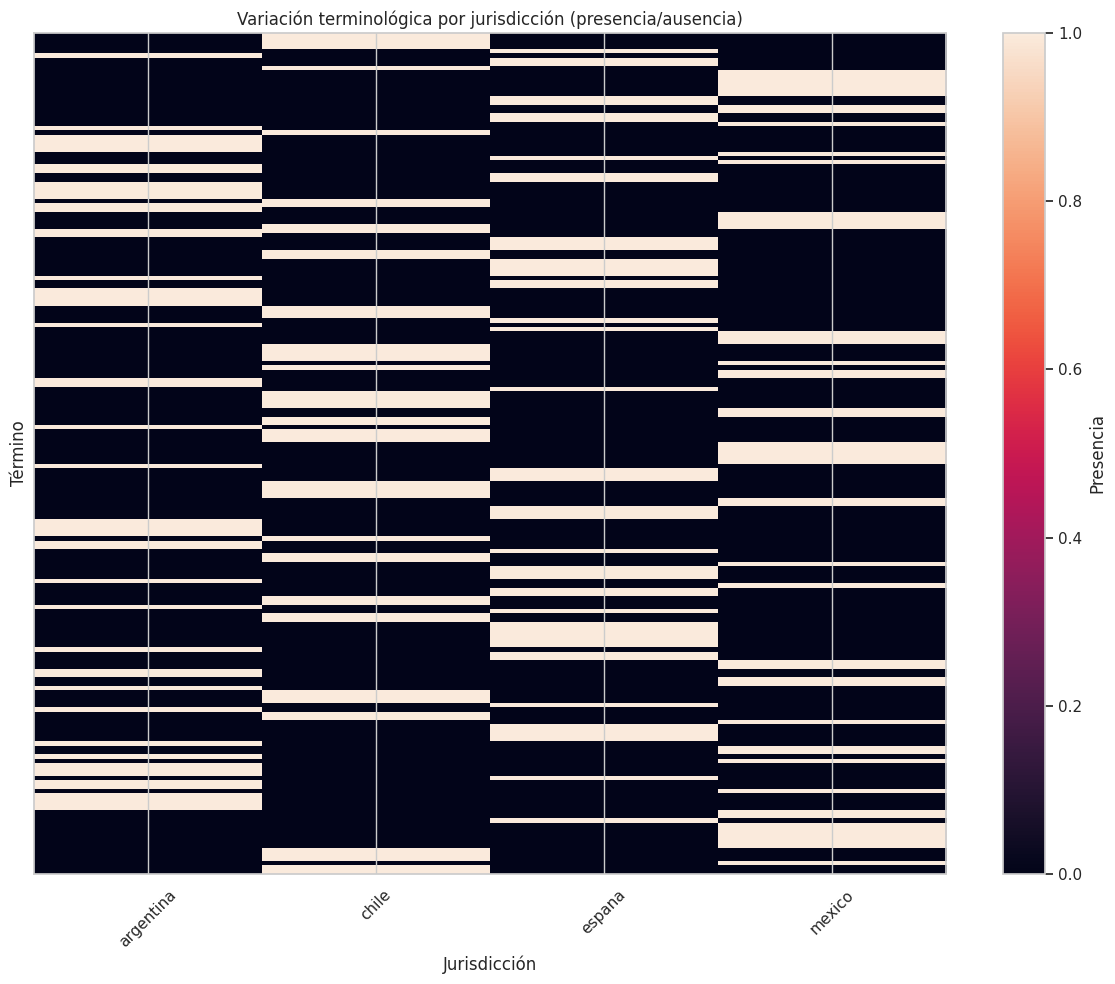


===== TÉRMINOS EXCLUSIVOS POR JURISDICCIÓN =====

ARGENTINA - 48 términos exclusivos
['acción amparo', 'buenos aires', 'citada garantía', 'ciudad buenos', 'ciudad buenos aires', 'civil comercial', 'conformidad será', 'conformidad será justicia', 'constitución nacional', 'constituido domicilio', 'constituyendo domicilio', 'constituyendo domicilio procesal', 'corte suprema justicia', 'daños perjuicios', 'domicilio calle', 'domicilio procesal', 'domicilio procesal material', 'domicilio real', 'domicilio real calle', 'electrónico clave']

CHILE - 47 términos exclusivos
['000 000', '19 123', '19 992', '20 874', 'agentes estado', 'cada uno', 'corte interamericana', 'derecho internacional', 'derechos humanos', 'don juan', 'don juan rené', 'doña rosa', 'estado chile', 'excepción prescripción', 'excma corte', 'excma corte suprema', 'fisco chile', 'hermanos víctima', 'identidad género', 'indemnización perjuicios']

ESPANA - 50 términos exclusivos
['520 lecrim', 'acreditado autos', 'acreditado a

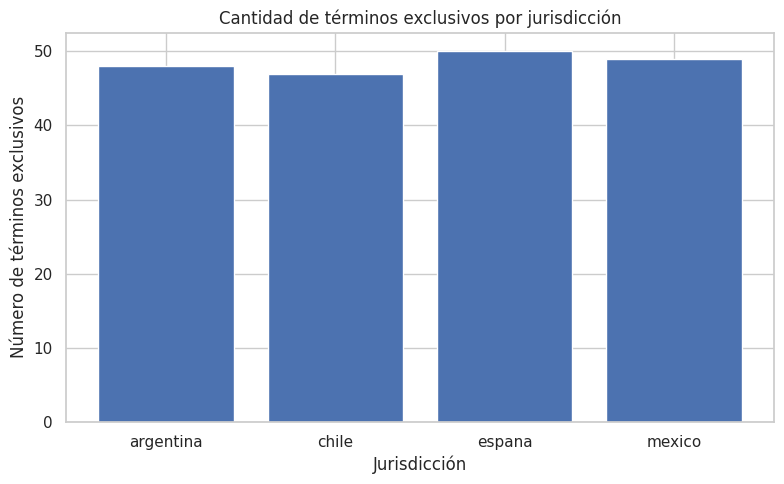


===== TÉRMINOS COMPARTIDOS POR TODAS LAS JURISDICCIONES =====
Cantidad: 0
[]


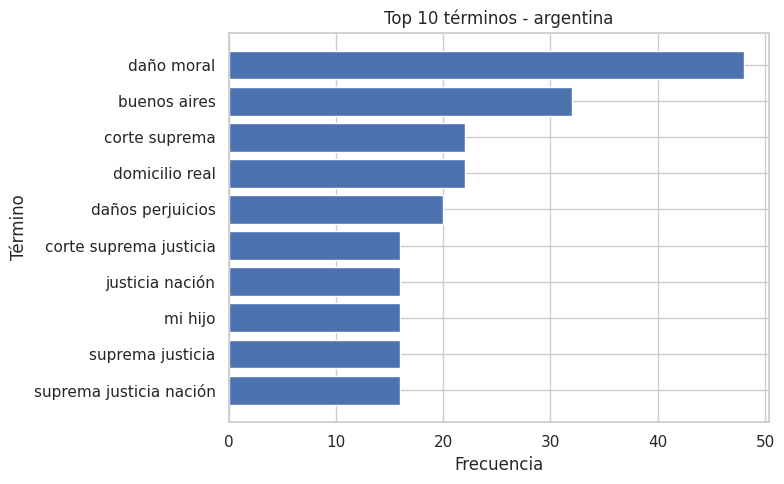

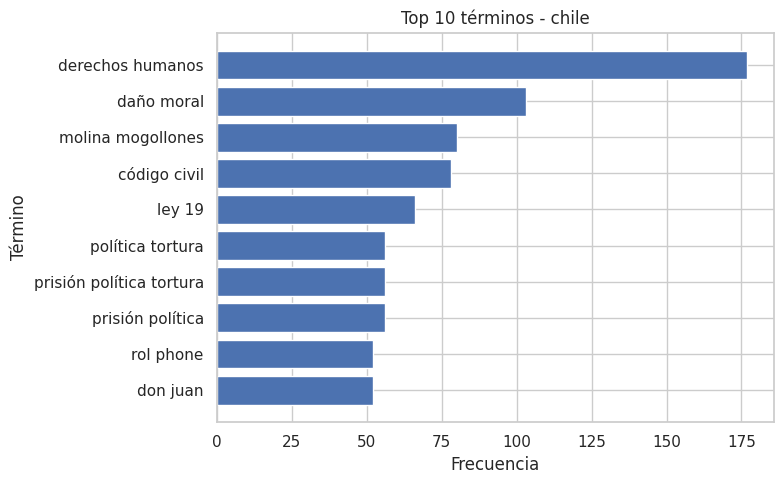

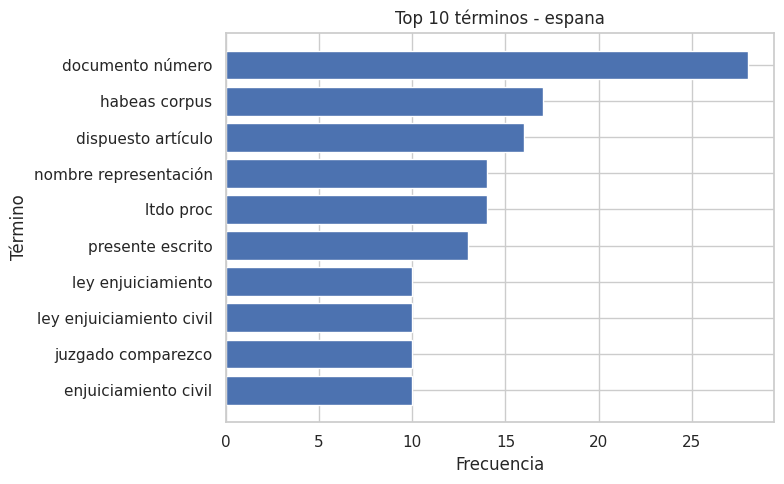

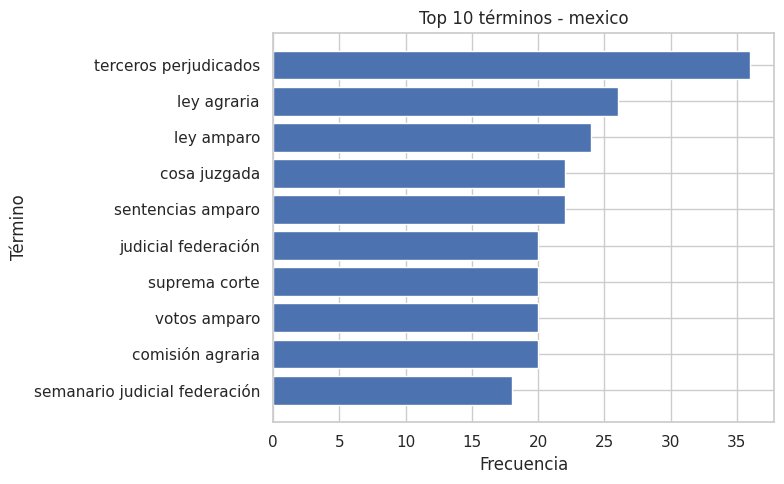


===== SIMILITUD TERMINOLÓGICA ENTRE JURISDICCIONES =====
  jurisdiction_1 jurisdiction_2  jaccard_similarity
0      argentina          chile              0.0204
4          chile         mexico              0.0101
1      argentina         espana              0.0000
2      argentina         mexico              0.0000
3          chile         espana              0.0000
5         espana         mexico              0.0000


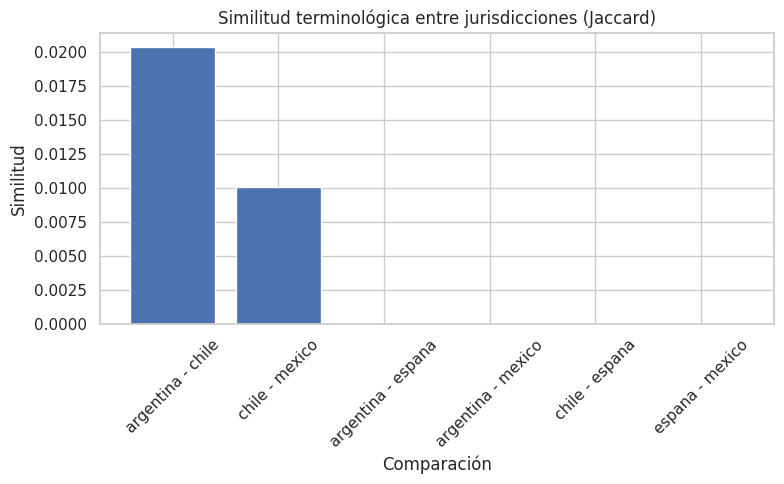


===== RESUMEN GENERAL =====
  jurisdiction  total_terms  exclusive_terms
0    argentina           50               48
1        chile           50               47
2       espana           50               50
3       mexico           50               49

Archivos guardados:
- terminos_por_jurisdiccion.csv
- matriz_terminos_jurisdiccion.csv
- matriz_presencia_jurisdiccion.csv
- similitud_jurisdicciones_jaccard.csv
- resumen_variacion_terminologica.csv
- terminos_exclusivos_por_jurisdiccion.csv


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from itertools import combinations

# ==========================================
# 1. CARGAR DATASET
# ==========================================
df = pd.read_csv("dataset_master_limpio.csv")

# ==========================================
# 2. LIMPIEZA BÁSICA
# ==========================================
df["jurisdiction"] = (
    df["jurisdiction"]
    .astype(str)
    .str.lower()
    .str.strip()
)

df["text_clean"] = (
    df["text_clean"]
    .fillna("")
    .astype(str)
    .str.strip()
)

# eliminar filas sin texto real
df = df[df["text_clean"] != ""]

# ==========================================
# 3. REVISIÓN INICIAL DEL CORPUS
# ==========================================
print("===== DOCUMENTOS POR JURISDICCIÓN =====")
print(df["jurisdiction"].value_counts())

print("\n===== JURISDICCIONES DETECTADAS =====")
print(sorted(df["jurisdiction"].unique()))

# ==========================================
# 4. STOPWORDS
# ==========================================
stopwords = [
    "de", "la", "que", "el", "en", "y", "a", "los", "del", "se", "las",
    "por", "un", "para", "con", "no", "una", "su", "al", "lo", "como",
    "más", "pero", "sus", "le", "ya", "o", "este", "sí", "porque",
    "esta", "entre", "cuando", "muy", "sin", "sobre", "también",
    "ha", "han", "ser", "es", "fue", "son", "era", "desde", "hasta",
    "contra", "ante", "durante", "mediante", "tras", "según"
]

# ==========================================
# 5. EXTRACCIÓN ROBUSTA DE TÉRMINOS POR PAÍS
# ==========================================
resultados = {}
top_n = 50

for country in sorted(df["jurisdiction"].unique()):
    sub = df[df["jurisdiction"] == country].copy()
    corpus = sub["text_clean"].dropna().tolist()

    print(f"\n===== PROCESANDO: {country.upper()} =====")
    print(f"Documentos: {len(corpus)}")

    if len(corpus) < 2:
        print(f"⚠️ Muy pocos documentos en {country}. Se omite.")
        continue

    try:
        vectorizer = CountVectorizer(
            ngram_range=(2, 3),
            min_df=1,       # más flexible para no perder países con pocos documentos
            max_df=0.90,
            stop_words=stopwords
        )

        X = vectorizer.fit_transform(corpus)
        terms = vectorizer.get_feature_names_out()
        freqs = X.sum(axis=0).A1

        df_terms = pd.DataFrame({
            "jurisdiction": country,
            "term": terms,
            "frequency": freqs
        }).sort_values(by="frequency", ascending=False)

        # filtro extra opcional: conservar solo términos con frecuencia >= 2
        df_terms = df_terms[df_terms["frequency"] >= 2]

        if df_terms.empty:
            print(f"⚠️ No se extrajeron términos frecuentes en {country}")
            continue

        resultados[country] = df_terms.head(top_n)

        print(f"✅ {country}: {len(df_terms)} términos extraídos")
        print(df_terms.head(10))

    except Exception as e:
        print(f"❌ Error en {country}: {e}")

# ==========================================
# 6. VERIFICAR PAÍSES INCLUIDOS
# ==========================================
print("\n===== JURISDICCIONES CON RESULTADOS =====")
print(list(resultados.keys()))

if len(resultados) == 0:
    raise ValueError("No se generaron resultados. Revisa el dataset o la columna text_clean.")

# ==========================================
# 7. UNIR RESULTADOS
# ==========================================
df_all = pd.concat(resultados.values(), ignore_index=True)

print("\n===== MUESTRA GENERAL DE TÉRMINOS =====")
print(df_all.head(20))

# ==========================================
# 8. MATRIZ TÉRMINO × JURISDICCIÓN
# ==========================================
matrix = df_all.pivot_table(
    index="term",
    columns="jurisdiction",
    values="frequency",
    aggfunc="sum",
    fill_value=0
)

presence = (matrix > 0).astype(int)

print("\n===== MATRIZ DE PRESENCIA/AUSENCIA =====")
print(presence.head(20))

# ==========================================
# 9. HEATMAP DE PRESENCIA/AUSENCIA
# ==========================================
plt.figure(figsize=(12, 10))
plt.imshow(presence, aspect="auto")
plt.title("Variación terminológica por jurisdicción (presencia/ausencia)")
plt.xlabel("Jurisdicción")
plt.ylabel("Término")
plt.xticks(range(len(presence.columns)), presence.columns, rotation=45)
plt.yticks([])  # ocultamos etiquetas para que no se vea saturado
plt.colorbar(label="Presencia")
plt.tight_layout()
plt.show()

# ==========================================
# 10. TÉRMINOS EXCLUSIVOS POR PAÍS
# ==========================================
exclusive_counts = {}
exclusive_terms_dict = {}

for country in presence.columns:
    exclusive_terms = presence[
        (presence[country] == 1) &
        (presence.drop(columns=[country]).sum(axis=1) == 0)
    ].index.tolist()

    exclusive_terms_dict[country] = exclusive_terms
    exclusive_counts[country] = len(exclusive_terms)

print("\n===== TÉRMINOS EXCLUSIVOS POR JURISDICCIÓN =====")
for country, terms in exclusive_terms_dict.items():
    print(f"\n{country.upper()} - {len(terms)} términos exclusivos")
    print(terms[:20])

plt.figure(figsize=(8, 5))
plt.bar(exclusive_counts.keys(), exclusive_counts.values())
plt.title("Cantidad de términos exclusivos por jurisdicción")
plt.xlabel("Jurisdicción")
plt.ylabel("Número de términos exclusivos")
plt.tight_layout()
plt.show()

# ==========================================
# 11. TÉRMINOS COMPARTIDOS POR TODAS LAS JURISDICCIONES
# ==========================================
shared_all = presence[presence.sum(axis=1) == len(presence.columns)].index.tolist()

print("\n===== TÉRMINOS COMPARTIDOS POR TODAS LAS JURISDICCIONES =====")
print(f"Cantidad: {len(shared_all)}")
print(shared_all[:30])

# ==========================================
# 12. TOP TÉRMINOS POR PAÍS
# ==========================================
for country in resultados.keys():
    df_country = resultados[country].head(10).sort_values("frequency", ascending=True)

    plt.figure(figsize=(8, 5))
    plt.barh(df_country["term"], df_country["frequency"])
    plt.title(f"Top 10 términos - {country}")
    plt.xlabel("Frecuencia")
    plt.ylabel("Término")
    plt.tight_layout()
    plt.show()

# ==========================================
# 13. SIMILITUD ENTRE JURISDICCIONES (JACCARD)
# ==========================================
def jaccard_similarity(set1, set2):
    inter = len(set1.intersection(set2))
    union = len(set1.union(set2))
    return inter / union if union != 0 else 0

country_term_sets = {
    country: set(df_all[df_all["jurisdiction"] == country]["term"])
    for country in presence.columns
}

sim_results = []

for c1, c2 in combinations(country_term_sets.keys(), 2):
    sim = jaccard_similarity(country_term_sets[c1], country_term_sets[c2])
    sim_results.append({
        "jurisdiction_1": c1,
        "jurisdiction_2": c2,
        "jaccard_similarity": round(sim, 4)
    })

df_similarity = pd.DataFrame(sim_results).sort_values(
    by="jaccard_similarity",
    ascending=False
)

print("\n===== SIMILITUD TERMINOLÓGICA ENTRE JURISDICCIONES =====")
print(df_similarity)

# gráfico de similitud
plt.figure(figsize=(8, 5))
labels = [f"{row['jurisdiction_1']} - {row['jurisdiction_2']}" for _, row in df_similarity.iterrows()]
values = df_similarity["jaccard_similarity"]

plt.bar(labels, values)
plt.title("Similitud terminológica entre jurisdicciones (Jaccard)")
plt.xlabel("Comparación")
plt.ylabel("Similitud")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ==========================================
# 14. RESUMEN GENERAL
# ==========================================
summary_rows = []

for country in presence.columns:
    total_terms = int(presence[country].sum())
    exclusive_count = int(exclusive_counts[country])

    summary_rows.append({
        "jurisdiction": country,
        "total_terms": total_terms,
        "exclusive_terms": exclusive_count
    })

df_summary = pd.DataFrame(summary_rows).sort_values(
    by="total_terms",
    ascending=False
)

print("\n===== RESUMEN GENERAL =====")
print(df_summary)

# ==========================================
# 15. GUARDAR RESULTADOS
# ==========================================
df_all.to_csv("terminos_por_jurisdiccion.csv", index=False, encoding="utf-8-sig")
matrix.to_csv("matriz_terminos_jurisdiccion.csv", encoding="utf-8-sig")
presence.to_csv("matriz_presencia_jurisdiccion.csv", encoding="utf-8-sig")
df_similarity.to_csv("similitud_jurisdicciones_jaccard.csv", index=False, encoding="utf-8-sig")
df_summary.to_csv("resumen_variacion_terminologica.csv", index=False, encoding="utf-8-sig")

# guardar exclusivos en CSV separado
exclusive_rows = []
for country, terms in exclusive_terms_dict.items():
    for term in terms:
        exclusive_rows.append({
            "jurisdiction": country,
            "exclusive_term": term
        })

df_exclusive = pd.DataFrame(exclusive_rows)
df_exclusive.to_csv("terminos_exclusivos_por_jurisdiccion.csv", index=False, encoding="utf-8-sig")

print("\nArchivos guardados:")
print("- terminos_por_jurisdiccion.csv")
print("- matriz_terminos_jurisdiccion.csv")
print("- matriz_presencia_jurisdiccion.csv")
print("- similitud_jurisdicciones_jaccard.csv")
print("- resumen_variacion_terminologica.csv")
print("- terminos_exclusivos_por_jurisdiccion.csv")